# Research Press Intensity Model

This notebook implements a standalone binary model where the only intensity concept is the research-paper-based `press_intensity` computed here.

The target is `press_success_any`:

- `1` = successful pressing episode
- `0` = unsuccessful pressing episode

The predictor is newly computed `press_intensity`, not `press_intensity_score` from any other notebook. The modelling rule is intentionally interpretable:

`pred_success = 1 if press_intensity >= threshold else 0`

Threshold selection uses train/validation data only. The test split is reserved for one final locked-threshold evaluation.

In [1]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    from kloppy import secondspectrum
except Exception as exc:
    secondspectrum = None
    KLOPPY_IMPORT_ERROR = exc
else:
    KLOPPY_IMPORT_ERROR = None

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Superliga_2024_2025_selected_TEST_DATA_3MATCHES":
    DATA_ROOT = PROJECT_ROOT
else:
    DATA_ROOT = PROJECT_ROOT / "Superliga_2024_2025_selected_TEST_DATA_3MATCHES"

EPISODE_SOURCE_PATH = DATA_ROOT / "press_features_settled_high_press.parquet" # THIS IS 10 MATCHES ONLY
#FULL SEASON "/Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_features_settled_high_press.parquet"
SPLIT_ASSIGNMENTS_PATH = DATA_ROOT / "press_model_split_assignments.parquet"
OUTPUT_DIR = DATA_ROOT / "research_press_intensity_model_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_INTENSITY_TABLE_PATH = OUTPUT_DIR / "research_press_intensity_episode_table.parquet"
THRESHOLD_TRAIN_RESULTS_PATH = OUTPUT_DIR / "research_press_intensity_threshold_train_results.csv"
THRESHOLD_VALIDATION_RESULTS_PATH = OUTPUT_DIR / "research_press_intensity_threshold_validation_results.csv"
THRESHOLD_MANIFEST_PATH = OUTPUT_DIR / "research_press_intensity_threshold_manifest.json"
TEST_METRICS_PATH = OUTPUT_DIR / "research_press_intensity_threshold_test_metrics.json"
TEST_PREDICTIONS_PATH = OUTPUT_DIR / "research_press_intensity_threshold_test_predictions.csv"

# Research-paper pressing intensity parameters.
T_WINDOW = 1.5
SIGMA = 0.45
TAU_R = 0.7
V_MAX = 8.0
V_ACTIVE = 2.0
SPRINT_THRESHOLD = 5.0
EPS = 1e-9
EARLY_PRESS_WINDOW = (0.0, 1.0)

RECOMPUTE_RESEARCH_PRESS_INTENSITY = False
RUN_OPTIONAL_LOGISTIC_REGRESSION = True

print(f"Data root: {DATA_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print("Research press_intensity parameters:")
print({
    "T_WINDOW": T_WINDOW,
    "SIGMA": SIGMA,
    "TAU_R": TAU_R,
    "V_MAX": V_MAX,
    "V_ACTIVE": V_ACTIVE,
    "SPRINT_THRESHOLD": SPRINT_THRESHOLD,
})
if secondspectrum is None:
    print(f"Kloppy import warning: {KLOPPY_IMPORT_ERROR}")

Data root: /Users/jonasaalbaekjensen/Desktop/MASTER_DS_SDU/Superliga_2024_2025_selected_TEST_DATA_3MATCHES
Output dir: /Users/jonasaalbaekjensen/Desktop/MASTER_DS_SDU/Superliga_2024_2025_selected_TEST_DATA_3MATCHES/research_press_intensity_model_outputs
Research press_intensity parameters:
{'T_WINDOW': 1.5, 'SIGMA': 0.45, 'TAU_R': 0.7, 'V_MAX': 8.0, 'V_ACTIVE': 2.0, 'SPRINT_THRESHOLD': 5.0}


## Method Definition

For each active defender-target pair, the notebook computes time-to-intercept as:

`T_i,j(t) = tau_r + tau_i,j(t) + tau_beta(t)`

That value is transformed into an interception probability using a logistic function, then defender probabilities are combined into total pressure:

`P_j = 1 - prod_i(1 - p_i,j)`

A defender contributes only when speed is at least `V_ACTIVE = 2.0 m/s`. In this implementation the ball location is used as the target because it is consistently available in the tracking data.

In [2]:
def load_episode_source() -> pd.DataFrame:
    if not EPISODE_SOURCE_PATH.exists():
        raise FileNotFoundError(f"Missing episode source: {EPISODE_SOURCE_PATH}")

    df = pd.read_parquet(EPISODE_SOURCE_PATH).reset_index(drop=True)

    # This notebook deliberately ignores intensity variables from other notebooks.
    ignored_intensity_cols = [c for c in df.columns if c == "press_intensity_score"]
    if ignored_intensity_cols:
        print(f"Ignoring old intensity columns: {ignored_intensity_cols}")
        df = df.drop(columns=ignored_intensity_cols)

    required_cols = ["match_name", "period", "gc_start", "team_side", "press_success_any"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Episode source is missing required columns: {missing}")

    if "episode_id" not in df.columns:
        df = df.copy()
        df.insert(0, "episode_id", np.arange(len(df), dtype=int))

    return df


def load_split_assignments() -> pd.DataFrame:
    if not SPLIT_ASSIGNMENTS_PATH.exists():
        raise FileNotFoundError(f"Missing split assignments: {SPLIT_ASSIGNMENTS_PATH}")
    splits = pd.read_parquet(SPLIT_ASSIGNMENTS_PATH).copy()
    required = {"match_name", "split"}
    missing = sorted(required.difference(splits.columns))
    if missing:
        raise ValueError(f"Split assignments are missing required columns: {missing}")
    return splits


episodes_base = load_episode_source()
split_assignments = load_split_assignments()

split_by_match = split_assignments.groupby("match_name")["split"].nunique()
bad_matches = split_by_match[split_by_match > 1]
if not bad_matches.empty:
    raise RuntimeError(f"Split leakage inside split assignment file: {bad_matches.to_dict()}")

match_to_split = split_assignments.drop_duplicates("match_name").set_index("match_name")["split"]
episodes_base["split"] = episodes_base["match_name"].map(match_to_split)

print(f"Loaded settled high-press episodes: {len(episodes_base):,}")
print(f"Matches: {episodes_base['match_name'].nunique():,}")
print(episodes_base["split"].value_counts(dropna=False).to_string())
display(episodes_base[[c for c in ["episode_id", "match_name", "period", "gc_start", "team_side", "press_success_any", "split"] if c in episodes_base.columns]].head())

Loaded settled high-press episodes: 626
Matches: 10
split
train         338
test          153
validation    135


,episode_id,match_name,period,gc_start,team_side,press_success_any,split
0,2024-07-19 AGF - FCM__1__away__00002,2024-07-19 AGF - FCM,1,134.4,away,1,train
1,2024-07-19 AGF - FCM__1__away__00003,2024-07-19 AGF - FCM,1,147.6,away,1,train
2,2024-07-19 AGF - FCM__1__away__00005,2024-07-19 AGF - FCM,1,250.2,away,0,train
3,2024-07-19 AGF - FCM__1__away__00006,2024-07-19 AGF - FCM,1,350.0,away,1,train
4,2024-07-19 AGF - FCM__1__away__00007,2024-07-19 AGF - FCM,1,435.2,away,1,train


In [3]:
def find_match_dir(match_name: str) -> Path:
    path = DATA_ROOT / str(match_name)
    if path.exists():
        return path
    candidates = [p for p in DATA_ROOT.iterdir() if p.is_dir() and str(match_name) in p.name]
    if len(candidates) == 1:
        return candidates[0]
    raise FileNotFoundError(f"Could not locate match folder for: {match_name}")


def load_tracking_kloppy(match_dir: Path):
    if secondspectrum is None:
        raise ImportError("kloppy is required to compute research press_intensity from raw tracking.") from KLOPPY_IMPORT_ERROR
    data_files = [f for f in match_dir.glob("*_SecondSpectrum_Data.json*") if f.suffix in (".json", ".jsonl")]
    if not data_files:
        raise FileNotFoundError(f"No SecondSpectrum data file found in {match_dir}")
    meta_xml = list(match_dir.glob("*_SecondSpectrum_Metadata.xml"))[0]
    meta_json = list(match_dir.glob("*_SecondSpectrum_Metadata.json"))[0]
    return secondspectrum.load(
        raw_data=str(data_files[0]),
        meta_data=str(meta_xml),
        additional_meta_data=str(meta_json),
        coordinates="secondspectrum",
    )


def kloppy_tracking_to_frame_table(dataset) -> pd.DataFrame:
    home_team = dataset.metadata.teams[0]
    away_team = dataset.metadata.teams[1]
    rows = []

    for frame_record in dataset.records:
        period = frame_record.period.id if frame_record.period else 1
        game_clock = frame_record.timestamp.total_seconds() if frame_record.timestamp else 0.0

        if frame_record.ball_coordinates:
            ball_x = frame_record.ball_coordinates.x
            ball_y = frame_record.ball_coordinates.y
            ball_z = getattr(frame_record.ball_coordinates, "z", 0.0) or 0.0
        else:
            ball_x, ball_y, ball_z = np.nan, np.nan, np.nan

        home_players = []
        away_players = []
        for player, coords in frame_record.players_coordinates.items():
            if coords is None:
                continue
            player_data = frame_record.players_data.get(player)
            speed = getattr(coords, "speed", None) or getattr(player_data, "speed", 0.0) or 0.0
            player_row = {
                "playerId": player.player_id,
                "xy": np.asarray([float(coords.x), float(coords.y)], dtype=float),
                "speed": float(speed),
            }
            if player.team == home_team:
                home_players.append(player_row)
            elif player.team == away_team:
                away_players.append(player_row)

        rows.append({
            "period": int(period),
            "gameClock": float(game_clock),
            "ball_x": float(ball_x) if pd.notna(ball_x) else np.nan,
            "ball_y": float(ball_y) if pd.notna(ball_y) else np.nan,
            "ball_z": float(ball_z) if pd.notna(ball_z) else np.nan,
            "home_players": home_players,
            "away_players": away_players,
        })

    return pd.DataFrame(rows).sort_values(["period", "gameClock"]).reset_index(drop=True)


def load_match_tracking(match_name: str) -> pd.DataFrame:
    match_dir = find_match_dir(match_name)
    dataset = load_tracking_kloppy(match_dir)
    try:
        tracking = kloppy_tracking_to_frame_table(dataset)
    finally:
        del dataset
    return tracking

In [4]:
def _players_for_side(frame: pd.Series | dict, side: str):
    if side == "home":
        return frame["home_players"]
    if side == "away":
        return frame["away_players"]
    raise ValueError("team_side must be 'home' or 'away'")


def _player_state_by_id(players):
    states = {}
    for player in players or []:
        player_id = player.get("playerId")
        xy = player.get("xy")
        if player_id is None or xy is None:
            continue
        xy = np.asarray(xy, dtype=float)
        if xy.shape[0] < 2 or np.any(pd.isna(xy[:2])):
            continue
        speed = player.get("speed", 0.0)
        states[str(player_id)] = {"xy": xy[:2], "speed": float(speed) if pd.notna(speed) else 0.0}
    return states


def _estimated_velocity(player_id: str, xy: np.ndarray, previous_states: dict, dt: float) -> np.ndarray:
    if previous_states is None or player_id not in previous_states or dt <= 0:
        return np.zeros(2, dtype=float)
    return (np.asarray(xy, dtype=float) - previous_states[player_id]["xy"]) / max(float(dt), 0.04)


def _ball_xy(frame: pd.Series | dict) -> np.ndarray:
    return np.asarray([frame.get("ball_x", np.nan), frame.get("ball_y", np.nan)], dtype=float)


def _ball_velocity(frame: pd.Series | dict, previous_frame: pd.Series | dict | None, dt: float) -> np.ndarray:
    if frame is None or previous_frame is None or dt <= 0:
        return np.zeros(2, dtype=float)
    current_xy = _ball_xy(frame)
    previous_xy = _ball_xy(previous_frame)
    if np.any(pd.isna(current_xy)) or np.any(pd.isna(previous_xy)):
        return np.zeros(2, dtype=float)
    return (current_xy - previous_xy) / max(float(dt), 0.04)


def _angular_penalty(player_velocity: np.ndarray, player_xy: np.ndarray, target_xy: np.ndarray) -> float:
    to_target = np.asarray(target_xy, dtype=float) - np.asarray(player_xy, dtype=float)
    distance = float(np.linalg.norm(to_target))
    speed = float(np.linalg.norm(player_velocity))
    if distance <= EPS or speed <= EPS:
        return 0.0
    alignment = float(np.dot(player_velocity, to_target) / max(speed * distance, EPS))
    return float(max(0.0, -alignment) * TAU_R)


def _time_to_intercept(player_xy: np.ndarray, player_velocity: np.ndarray, target_xy: np.ndarray, target_velocity: np.ndarray) -> float:
    player_future = np.asarray(player_xy, dtype=float) + np.asarray(player_velocity, dtype=float) * TAU_R
    target_future = np.asarray(target_xy, dtype=float) + np.asarray(target_velocity, dtype=float) * TAU_R
    distance_after_reaction = float(np.linalg.norm(target_future - player_future))
    travel_time = distance_after_reaction / max(float(V_MAX), EPS)
    return float(TAU_R + travel_time + _angular_penalty(player_velocity, player_xy, target_xy))


def _intercept_probability(time_to_intercept: float) -> float:
    if pd.isna(time_to_intercept):
        return np.nan
    scale = math.pi / (math.sqrt(3.0) * max(float(SIGMA), EPS))
    z = np.clip(scale * (float(T_WINDOW) - float(time_to_intercept)), -50.0, 50.0)
    return float(1.0 / (1.0 + np.exp(-z)))


def frame_research_press_intensity(frame: pd.Series, previous_frame: pd.Series | None, pressing_side: str) -> dict:
    target_xy = _ball_xy(frame)
    if np.any(pd.isna(target_xy)):
        return {"press_intensity": np.nan, "max_individual_pressure": np.nan, "n_active_pressers": 0, "n_pressers_evaluated": 0}

    frame_gc = float(frame.get("gameClock", np.nan))
    previous_gc = float(previous_frame.get("gameClock", np.nan)) if previous_frame is not None else np.nan
    dt = max(frame_gc - previous_gc, 0.04) if pd.notna(frame_gc) and pd.notna(previous_gc) else 0.04

    current_states = _player_state_by_id(_players_for_side(frame, pressing_side))
    previous_states = _player_state_by_id(_players_for_side(previous_frame, pressing_side)) if previous_frame is not None else {}
    target_velocity = _ball_velocity(frame, previous_frame, dt)

    probabilities = []
    active_count = 0
    for player_id, state in current_states.items():
        player_speed = float(state["speed"])
        if player_speed < V_ACTIVE:
            probabilities.append(0.0)
            continue
        active_count += 1
        player_velocity = _estimated_velocity(player_id, state["xy"], previous_states, dt)
        tti = _time_to_intercept(state["xy"], player_velocity, target_xy, target_velocity)
        probabilities.append(_intercept_probability(tti))

    if not probabilities:
        total_pressure = 0.0
        max_pressure = 0.0
    else:
        probs = np.nan_to_num(np.clip(np.asarray(probabilities, dtype=float), 0.0, 1.0), nan=0.0)
        total_pressure = float(1.0 - np.prod(1.0 - probs))
        max_pressure = float(probs.max())

    return {
        "press_intensity": total_pressure,
        "max_individual_pressure": max_pressure,
        "n_active_pressers": int(active_count),
        "n_pressers_evaluated": int(len(current_states)),
    }

In [5]:
def compute_episode_research_press_intensity(episode: pd.Series, tracking: pd.DataFrame) -> dict:
    period = int(episode["period"])
    start_gc = float(episode["gc_start"])
    rel_start, rel_end = EARLY_PRESS_WINDOW
    t0 = start_gc + rel_start
    t1 = start_gc + rel_end
    pressing_side = str(episode["team_side"])

    period_tracking = tracking[tracking["period"].astype(int).eq(period)].sort_values("gameClock").reset_index(drop=True)
    if period_tracking.empty:
        return {"press_intensity": np.nan, "press_intensity_peak": np.nan, "press_intensity_std": np.nan, "n_intensity_frames": 0}

    window = period_tracking[period_tracking["gameClock"].between(t0, t1)].copy()
    if window.empty:
        return {"press_intensity": np.nan, "press_intensity_peak": np.nan, "press_intensity_std": np.nan, "n_intensity_frames": 0}

    values = []
    max_individual = []
    active_pressers = []
    evaluated_pressers = []

    previous_candidates = period_tracking[period_tracking["gameClock"] < float(window.iloc[0]["gameClock"])]
    previous_frame = previous_candidates.iloc[-1] if not previous_candidates.empty else None

    for _, frame in window.iterrows():
        result = frame_research_press_intensity(frame, previous_frame, pressing_side)
        values.append(result["press_intensity"])
        max_individual.append(result["max_individual_pressure"])
        active_pressers.append(result["n_active_pressers"])
        evaluated_pressers.append(result["n_pressers_evaluated"])
        previous_frame = frame

    values = pd.Series(values, dtype="float64").replace([np.inf, -np.inf], np.nan).dropna()
    max_individual = pd.Series(max_individual, dtype="float64").replace([np.inf, -np.inf], np.nan).dropna()

    return {
        "press_intensity": float(values.mean()) if not values.empty else np.nan,
        "press_intensity_peak": float(values.max()) if not values.empty else np.nan,
        "press_intensity_std": float(values.std(ddof=0)) if len(values) > 1 else 0.0 if len(values) == 1 else np.nan,
        "max_individual_pressure_mean": float(max_individual.mean()) if not max_individual.empty else np.nan,
        "n_active_pressers_mean": float(np.nanmean(active_pressers)) if len(active_pressers) else np.nan,
        "n_pressers_evaluated_mean": float(np.nanmean(evaluated_pressers)) if len(evaluated_pressers) else np.nan,
        "n_intensity_frames": int(len(values)),
    }


def compute_research_press_intensity_table(episodes: pd.DataFrame) -> pd.DataFrame:
    if RESEARCH_INTENSITY_TABLE_PATH.exists() and not RECOMPUTE_RESEARCH_PRESS_INTENSITY:
        print(f"Loading cached research press_intensity table: {RESEARCH_INTENSITY_TABLE_PATH}")
        return pd.read_parquet(RESEARCH_INTENSITY_TABLE_PATH)

    rows = []
    match_names = sorted(episodes["match_name"].dropna().astype(str).unique())
    for idx, match_name in enumerate(match_names, 1):
        match_episodes = episodes[episodes["match_name"].astype(str).eq(match_name)].copy()
        print(f"[{idx}/{len(match_names)}] Computing research press_intensity: {match_name} ({len(match_episodes):,} episodes)")
        tracking = load_match_tracking(match_name)
        for _, episode in match_episodes.iterrows():
            out = compute_episode_research_press_intensity(episode, tracking)
            for key in ["episode_id", "match_name", "period", "gc_start", "team_side", "team_id", "press_success_any", "split"]:
                if key in episode.index:
                    out[key] = episode[key]
            rows.append(out)
        del tracking

    intensity_df = pd.DataFrame(rows)
    metadata = {
        "created_by": "MASTER_PRESS_INTENSITY_MODEL.ipynb",
        "variable": "press_intensity",
        "ignored_variable": "press_intensity_score",
        "target": "press_success_any",
        "window": {"start": EARLY_PRESS_WINDOW[0], "end": EARLY_PRESS_WINDOW[1]},
        "parameters": {"T_WINDOW": T_WINDOW, "SIGMA": SIGMA, "TAU_R": TAU_R, "V_MAX": V_MAX, "V_ACTIVE": V_ACTIVE},
        "n_rows": int(len(intensity_df)),
    }
    intensity_df.attrs["research_press_intensity_metadata"] = metadata
    intensity_df.to_parquet(RESEARCH_INTENSITY_TABLE_PATH, index=False)
    with open(OUTPUT_DIR / "research_press_intensity_computation_metadata.json", "w") as fh:
        json.dump(metadata, fh, indent=2)
    print(f"Saved: {RESEARCH_INTENSITY_TABLE_PATH}")
    return intensity_df


research_intensity_df = compute_research_press_intensity_table(episodes_base)
print(research_intensity_df[["press_intensity", "press_success_any", "split"]].describe(include="all"))
display(research_intensity_df.head())

[1/10] Computing research press_intensity: 2024-07-19 AGF - FCM (60 episodes)
[2/10] Computing research press_intensity: 2024-07-19 FCN - AAB (90 episodes)
[3/10] Computing research press_intensity: 2024-07-21 SIF - SJE (43 episodes)
[4/10] Computing research press_intensity: 2024-07-21 Vejle Boldklub - Randers FC (2442548) (42 episodes)
[5/10] Computing research press_intensity: 2024-07-21 Viborg FF - Brøndby IF (2442549) (60 episodes)
[6/10] Computing research press_intensity: 2024-07-22 Lyngby Boldklub - F.C. København (2442550) (62 episodes)
[7/10] Computing research press_intensity: 2024-10-06 Brøndby IF - FC Midtjylland (2442605) (57 episodes)
[8/10] Computing research press_intensity: 2024-11-24 F.C. København - Lyngby Boldklub (2442635) (74 episodes)
[9/10] Computing research press_intensity: 2025-03-16 SønderjyskE - AaB (2442676) (63 episodes)
[10/10] Computing research press_intensity: 2025-05-04 FC Midtjylland - AGF (2515614) (75 episodes)
Saved: /Users/jonasaalbaekjensen/De

,press_intensity,press_intensity_peak,press_intensity_std,max_individual_pressure_mean,n_active_pressers_mean,n_pressers_evaluated_mean,n_intensity_frames,episode_id,match_name,period,gc_start,team_side,team_id,press_success_any,split
0,0.930255,0.992085,0.091710,0.815843,4.192308,11.0,26,2024-07-19 AGF - FCM__1__away__00002,2024-07-19 AGF - FCM,1,134.4,away,1000,1,train
1,0.216854,0.614783,0.121241,0.216627,10.000000,11.0,26,2024-07-19 AGF - FCM__1__away__00003,2024-07-19 AGF - FCM,1,147.6,away,1000,1,train
2,0.464721,0.721129,0.177265,0.464490,4.576923,11.0,26,2024-07-19 AGF - FCM__1__away__00005,2024-07-19 AGF - FCM,1,250.2,away,1000,0,train
3,0.225339,0.456616,0.124750,0.220556,8.884615,11.0,26,2024-07-19 AGF - FCM__1__away__00006,2024-07-19 AGF - FCM,1,350.0,away,1000,1,train
4,0.445376,0.857913,0.278930,0.444635,6.076923,11.0,26,2024-07-19 AGF - FCM__1__away__00007,2024-07-19 AGF - FCM,1,435.2,away,1000,1,train


In [6]:
def prepare_modelling_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    required = ["press_intensity", "press_success_any", "match_name", "split"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required modelling columns: {missing}")

    model_df = df.copy()
    model_df = model_df.replace([np.inf, -np.inf], np.nan)
    model_df = model_df.dropna(subset=["press_intensity", "press_success_any", "match_name", "split"]).reset_index(drop=True)
    model_df["press_success_any"] = model_df["press_success_any"].astype(int)

    outside_range = model_df[~model_df["press_intensity"].between(0.0, 1.0)]
    if len(outside_range) > 0:
        warnings.warn(f"{len(outside_range)} rows have press_intensity outside [0, 1]. They will be clipped for modelling.")
        model_df["press_intensity"] = model_df["press_intensity"].clip(0.0, 1.0)

    splits_by_match = model_df.groupby("match_name")["split"].nunique()
    overlap = splits_by_match[splits_by_match > 1]
    if not overlap.empty:
        raise RuntimeError(f"Match leakage across splits detected: {overlap.to_dict()}")

    expected_splits = {"train", "validation", "test"}
    present_splits = set(model_df["split"].dropna().astype(str).unique())
    missing_splits = expected_splits - present_splits
    if missing_splits:
        raise RuntimeError(f"Missing required splits: {sorted(missing_splits)}")

    return model_df


model_df = prepare_modelling_dataframe(research_intensity_df)

split_summary = model_df.groupby("split").agg(
    rows=("press_success_any", "size"),
    matches=("match_name", "nunique"),
    success_rate=("press_success_any", "mean"),
    mean_press_intensity=("press_intensity", "mean"),
).reset_index()
display(split_summary)

train_df = model_df[model_df["split"].eq("train")].copy()
validation_df = model_df[model_df["split"].eq("validation")].copy()
test_df = model_df[model_df["split"].eq("test")].copy()

print(f"Modelling rows: {len(model_df):,}")
print(f"Train rows: {len(train_df):,} | Validation rows: {len(validation_df):,} | Test rows: {len(test_df):,}")

,split,rows,matches,success_rate,mean_press_intensity
0,test,153,2,0.470588,0.640422
1,train,338,6,0.514793,0.575567
2,validation,135,2,0.496296,0.559900


Modelling rows: 626
Train rows: 338 | Validation rows: 135 | Test rows: 153


,count,mean,std,min,25%,50%,75%,max
press_success_any,,,,,,,,
0,164.0,0.54085,0.282528,0.006690,0.325662,0.585851,0.789016,0.989329
1,174.0,0.60829,0.258825,0.061429,0.390090,0.670436,0.818782,0.989945


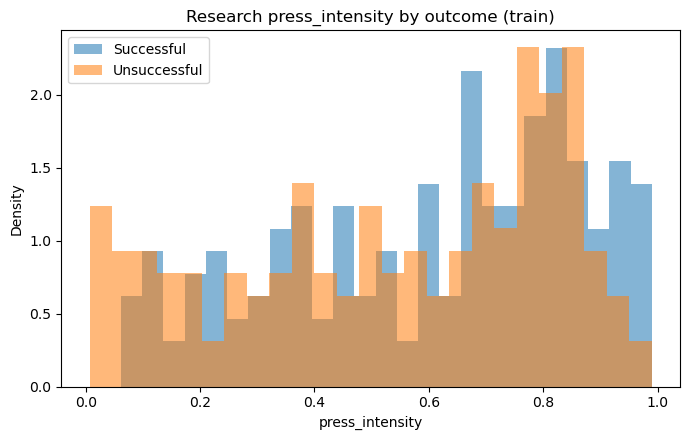

,intensity_decile,n_episodes,mean_press_intensity,success_rate
0,"(0.00569, 0.156]",34,0.078936,0.294118
1,"(0.156, 0.307]",34,0.226943,0.529412
2,"(0.307, 0.416]",34,0.363914,0.500000
3,"(0.416, 0.526]",33,0.469892,0.515152
4,"(0.526, 0.651]",34,0.586029,0.500000
5,"(0.651, 0.713]",34,0.682947,0.647059
6,"(0.713, 0.786]",33,0.754731,0.424242
7,"(0.786, 0.831]",34,0.805647,0.558824
8,"(0.831, 0.882]",34,0.854975,0.470588
9,"(0.882, 0.99]",34,0.933821,0.705882


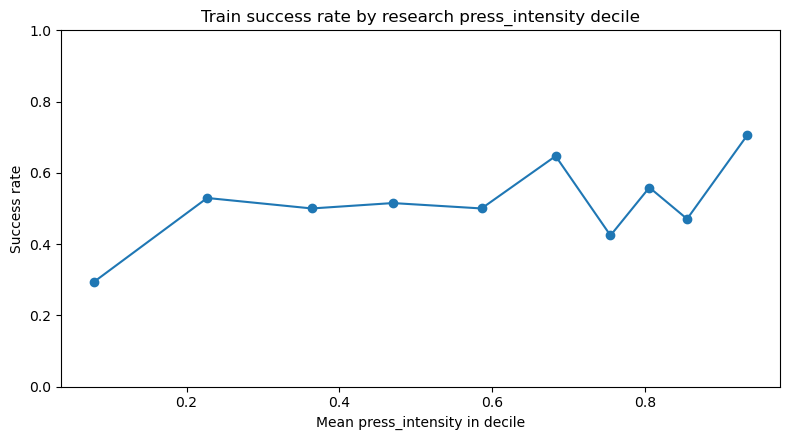

In [7]:
PLOT_DISTRIBUTION_PATH = OUTPUT_DIR / "research_press_intensity_distribution_10Matches_by_success.png"
PLOT_BIN_SUCCESS_PATH = OUTPUT_DIR / "research_press_intensity_success_10Matches_by_decile.png"

train_stats = train_df.groupby("press_success_any")["press_intensity"].describe()
display(train_stats)

plot_train = train_df.copy()
plot_train["success_label"] = plot_train["press_success_any"].map({0: "Unsuccessful", 1: "Successful"})

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, group in plot_train.groupby("success_label"):
    ax.hist(group["press_intensity"], bins=25, alpha=0.55, label=label, density=True)
ax.set_title("Research press_intensity by outcome (train)")
ax.set_xlabel("press_intensity")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DISTRIBUTION_PATH, dpi=220, bbox_inches="tight")
plt.show()

train_bins = train_df.copy()
train_bins["intensity_decile"] = pd.qcut(train_bins["press_intensity"], q=10, duplicates="drop")
decile_summary = train_bins.groupby("intensity_decile", observed=False).agg(
    n_episodes=("press_success_any", "size"),
    mean_press_intensity=("press_intensity", "mean"),
    success_rate=("press_success_any", "mean"),
).reset_index()
decile_summary["intensity_decile"] = decile_summary["intensity_decile"].astype(str)
display(decile_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(decile_summary["mean_press_intensity"], decile_summary["success_rate"], marker="o")
ax.set_ylim(0, 1)
ax.set_title("Train success rate by research press_intensity decile")
ax.set_xlabel("Mean press_intensity in decile")
ax.set_ylabel("Success rate")
fig.tight_layout()
fig.savefig(PLOT_BIN_SUCCESS_PATH, dpi=220, bbox_inches="tight")
plt.show()

,intensity_quartile,n_episodes,mean_press_intensity,success_rate
0,Q1,85,0.190573,0.435294
1,Q2,84,0.500067,0.500000
2,Q3,84,0.733401,0.535714
3,Q4,85,0.879196,0.588235


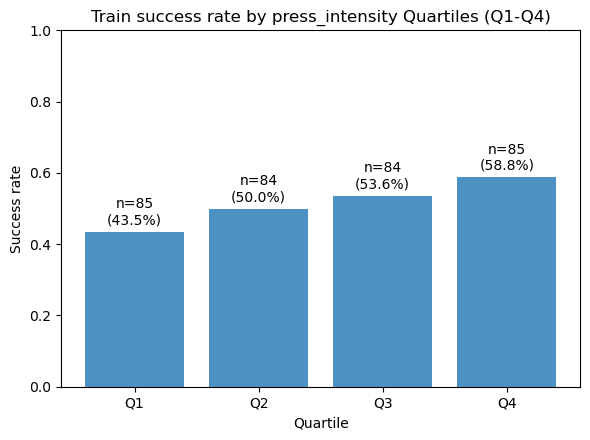

In [18]:
PLOT_QUARTILE_SUCCESS_PATH = OUTPUT_DIR / "research_press_intensity_success_10Matches_by_quartile.png"

train_quartiles = train_df.copy()
train_quartiles["intensity_quartile"] = pd.qcut(train_quartiles["press_intensity"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
quartile_summary = train_quartiles.groupby("intensity_quartile", observed=False).agg(
    n_episodes=("press_success_any", "size"),
    mean_press_intensity=("press_intensity", "mean"),
    success_rate=("press_success_any", "mean"),
).reset_index()
display(quartile_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(quartile_summary["intensity_quartile"], quartile_summary["success_rate"], color="#1f77b4", alpha=0.8)
ax.set_ylim(0, 1)
ax.set_title("Train success rate by press_intensity Quartiles (Q1-Q4)")
ax.set_xlabel("Quartile")
ax.set_ylabel("Success rate")
for idx, row in quartile_summary.iterrows():
    label_height = row["success_rate"] + 0.02 if pd.notna(row["success_rate"]) else 0.02
    ax.text(idx, label_height, f"n={int(row['n_episodes'])}\n({row['success_rate']*100:.1f}%)", ha="center")
fig.tight_layout()
fig.savefig(PLOT_QUARTILE_SUCCESS_PATH, dpi=220, bbox_inches="tight")
plt.show()

In [8]:
def threshold_metrics(y_true, scores, threshold: float) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    y_pred = (scores >= float(threshold)).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "tpr": float(recall_score(y_true, y_pred, zero_division=0)),
        "fpr": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
        "n": int(len(y_true)),
    }


def make_train_threshold_grid(train_scores: pd.Series) -> np.ndarray:
    scores = train_scores.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    percentile_grid = np.nanpercentile(scores, np.linspace(1, 99, 99))
    if scores.nunique() <= 500:
        candidates = np.r_[percentile_grid, scores.unique()]
    else:
        candidates = percentile_grid
    return np.unique(np.clip(candidates, 0.0, 1.0))


def scan_thresholds(df: pd.DataFrame, thresholds: np.ndarray) -> pd.DataFrame:
    y_true = df["press_success_any"].astype(int).to_numpy()
    scores = df["press_intensity"].astype(float).to_numpy()
    return pd.DataFrame([threshold_metrics(y_true, scores, threshold) for threshold in thresholds])


candidate_thresholds = make_train_threshold_grid(train_df["press_intensity"])
train_threshold_results = scan_thresholds(train_df, candidate_thresholds)
validation_threshold_results = scan_thresholds(validation_df, candidate_thresholds)

train_threshold_results.to_csv(THRESHOLD_TRAIN_RESULTS_PATH, index=False)
validation_threshold_results.to_csv(THRESHOLD_VALIDATION_RESULTS_PATH, index=False)

print(f"Candidate thresholds generated from train only: {len(candidate_thresholds):,}")
display(validation_threshold_results.sort_values(["f1", "balanced_accuracy"], ascending=[False, False]).head(10))

Candidate thresholds generated from train only: 437


,threshold,accuracy,precision,recall,specificity,f1,balanced_accuracy,tpr,fpr,tp,fp,tn,fn,n
65,0.219296,0.540741,0.520661,0.940299,0.147059,0.670213,0.543679,0.940299,0.852941,63,58,10,4,135
66,0.221294,0.540741,0.520661,0.940299,0.147059,0.670213,0.543679,0.940299,0.852941,63,58,10,4,135
67,0.223330,0.540741,0.520661,0.940299,0.147059,0.670213,0.543679,0.940299,0.852941,63,58,10,4,135
68,0.225339,0.540741,0.520661,0.940299,0.147059,0.670213,0.543679,0.940299,0.852941,63,58,10,4,135
69,0.226985,0.540741,0.520661,0.940299,0.147059,0.670213,0.543679,0.940299,0.852941,63,58,10,4,135
70,0.227128,0.540741,0.520661,0.940299,0.147059,0.670213,0.543679,0.940299,0.852941,63,58,10,4,135
8,0.039913,0.511111,0.503759,1.000000,0.029412,0.670000,0.514706,1.000000,0.970588,67,66,2,0,135
9,0.041804,0.511111,0.503759,1.000000,0.029412,0.670000,0.514706,1.000000,0.970588,67,66,2,0,135
10,0.046088,0.511111,0.503759,1.000000,0.029412,0.670000,0.514706,1.000000,0.970588,67,66,2,0,135
11,0.055426,0.511111,0.503759,1.000000,0.029412,0.670000,0.514706,1.000000,0.970588,67,66,2,0,135


In [9]:
def select_final_threshold(validation_results: pd.DataFrame) -> tuple[float, str, pd.Series]:
    selected = validation_results.sort_values(["f1", "balanced_accuracy", "threshold"], ascending=[False, False, True]).iloc[0]
    return float(selected["threshold"]), "max_validation_f1", selected


def alternative_thresholds(validation_results: pd.DataFrame) -> dict:
    alternatives = {}
    youden = validation_results.assign(youden=validation_results["tpr"] - validation_results["fpr"])
    alternatives["youden"] = youden.sort_values(["youden", "f1"], ascending=[False, False]).iloc[0].to_dict()

    precision_constrained = validation_results[validation_results["precision"] >= 0.70]
    if not precision_constrained.empty:
        alternatives["precision_at_least_0_70"] = precision_constrained.sort_values(["recall", "f1"], ascending=[False, False]).iloc[0].to_dict()

    recall_constrained = validation_results[validation_results["recall"] >= 0.70]
    if not recall_constrained.empty:
        alternatives["recall_at_least_0_70"] = recall_constrained.sort_values(["precision", "f1"], ascending=[False, False]).iloc[0].to_dict()

    top_quartile_threshold = float(train_df["press_intensity"].quantile(0.75))
    alternatives["train_top_quartile"] = threshold_metrics(
        validation_df["press_success_any"],
        validation_df["press_intensity"],
        top_quartile_threshold,
    )
    return alternatives


final_threshold, threshold_selection_rule, validation_selected_row = select_final_threshold(validation_threshold_results)
train_selected_row = train_threshold_results.iloc[(train_threshold_results["threshold"] - final_threshold).abs().argmin()]
threshold_alternatives = alternative_thresholds(validation_threshold_results)

threshold_manifest = {
    "model_name": "research_press_intensity_threshold_binary_success",
    "predictor": "press_intensity",
    "ignored_predictor": "press_intensity_score",
    "target": "press_success_any",
    "prediction_rule": "press_success_pred = int(press_intensity >= final_threshold)",
    "final_threshold": float(final_threshold),
    "selection_rule": threshold_selection_rule,
    "test_usage_note": "The test split was not used for threshold selection.",
    "paper_parameters": {"T_WINDOW": T_WINDOW, "SIGMA": SIGMA, "TAU_R": TAU_R, "V_MAX": V_MAX, "V_ACTIVE": V_ACTIVE},
    "train_metrics_at_final_threshold": train_selected_row.to_dict(),
    "validation_metrics_at_final_threshold": validation_selected_row.to_dict(),
    "alternative_validation_thresholds": threshold_alternatives,
    "n_rows": {"train": int(len(train_df)), "validation": int(len(validation_df)), "test": int(len(test_df))},
}

with open(THRESHOLD_MANIFEST_PATH, "w") as fh:
    json.dump(threshold_manifest, fh, indent=2)

print(f"Final threshold locked: {final_threshold:.6f}")
print(f"Selection rule: {threshold_selection_rule}")
print(f"Saved manifest: {THRESHOLD_MANIFEST_PATH}")
display(pd.DataFrame([train_selected_row.to_dict(), validation_selected_row.to_dict()], index=["train", "validation"]))

Final threshold locked: 0.219296
Selection rule: max_validation_f1
Saved manifest: /Users/jonasaalbaekjensen/Desktop/MASTER_DS_SDU/Superliga_2024_2025_selected_TEST_DATA_3MATCHES/research_press_intensity_model_outputs/research_press_intensity_threshold_manifest.json


,threshold,accuracy,precision,recall,specificity,f1,balanced_accuracy,tpr,fpr,tp,fp,tn,fn,n
train,0.219296,0.553254,0.540070,0.890805,0.195122,0.672451,0.542963,0.890805,0.804878,155.0,132.0,32.0,19.0,338.0
validation,0.219296,0.540741,0.520661,0.940299,0.147059,0.670213,0.543679,0.940299,0.852941,63.0,58.0,10.0,4.0,135.0


In [10]:
def raw_score_auc_metrics(df: pd.DataFrame) -> dict:
    y_true = df["press_success_any"].astype(int).to_numpy()
    scores = df["press_intensity"].astype(float).to_numpy()
    if len(np.unique(y_true)) < 2:
        return {"roc_auc": np.nan, "pr_auc": np.nan}
    return {
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
    }


test_threshold_metrics = threshold_metrics(
    test_df["press_success_any"],
    test_df["press_intensity"],
    final_threshold,
)
test_threshold_metrics.update(raw_score_auc_metrics(test_df))

test_predictions = test_df.copy()
test_predictions["press_success_pred"] = (test_predictions["press_intensity"] >= final_threshold).astype(int)
above = test_predictions[test_predictions["press_intensity"] >= final_threshold]
below = test_predictions[test_predictions["press_intensity"] < final_threshold]

test_threshold_metrics.update({
    "final_threshold": float(final_threshold),
    "test_base_success_rate": float(test_predictions["press_success_any"].mean()),
    "success_rate_above_threshold": float(above["press_success_any"].mean()) if len(above) else np.nan,
    "success_rate_below_threshold": float(below["press_success_any"].mean()) if len(below) else np.nan,
    "n_above_threshold": int(len(above)),
    "n_below_threshold": int(len(below)),
})

with open(TEST_METRICS_PATH, "w") as fh:
    json.dump(test_threshold_metrics, fh, indent=2)
test_predictions.to_csv(TEST_PREDICTIONS_PATH, index=False)

print("Final untouched test evaluation complete.")
print(json.dumps(test_threshold_metrics, indent=2))
display(pd.DataFrame([test_threshold_metrics]))

Final untouched test evaluation complete.
{
  "threshold": 0.21929597384872798,
  "accuracy": 0.46405228758169936,
  "precision": 0.4647887323943662,
  "recall": 0.9166666666666666,
  "specificity": 0.06172839506172839,
  "f1": 0.616822429906542,
  "balanced_accuracy": 0.4891975308641975,
  "tpr": 0.9166666666666666,
  "fpr": 0.9382716049382716,
  "tp": 66,
  "fp": 76,
  "tn": 5,
  "fn": 6,
  "n": 153,
  "roc_auc": 0.5504115226337449,
  "pr_auc": 0.5961041737267491,
  "final_threshold": 0.21929597384872798,
  "test_base_success_rate": 0.47058823529411764,
  "success_rate_above_threshold": 0.4647887323943662,
  "success_rate_below_threshold": 0.5454545454545454,
  "n_above_threshold": 142,
  "n_below_threshold": 11
}


,threshold,accuracy,precision,recall,specificity,f1,balanced_accuracy,tpr,fpr,tp,...,fn,n,roc_auc,pr_auc,final_threshold,test_base_success_rate,success_rate_above_threshold,success_rate_below_threshold,n_above_threshold,n_below_threshold
0,0.219296,0.464052,0.464789,0.916667,0.061728,0.616822,0.489198,0.916667,0.938272,66,...,6,153,0.550412,0.596104,0.219296,0.470588,0.464789,0.545455,142,11


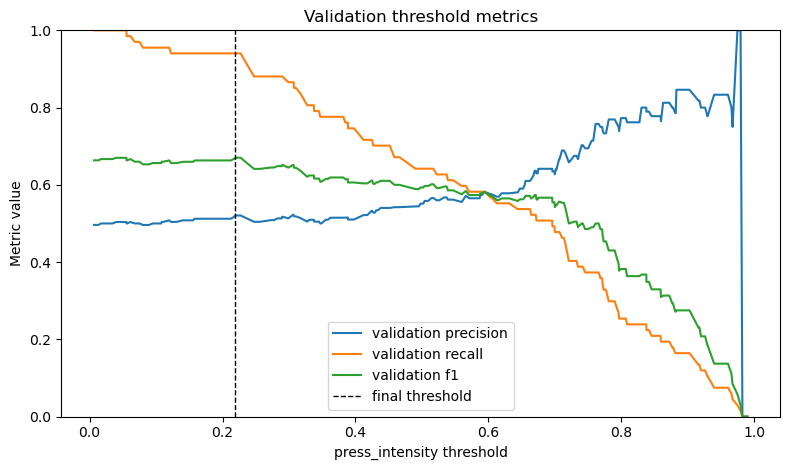

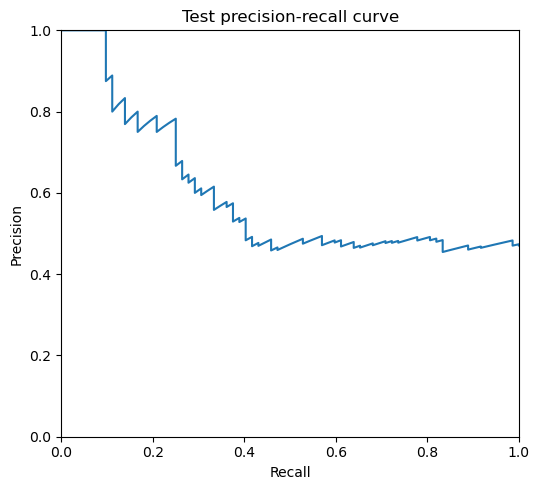

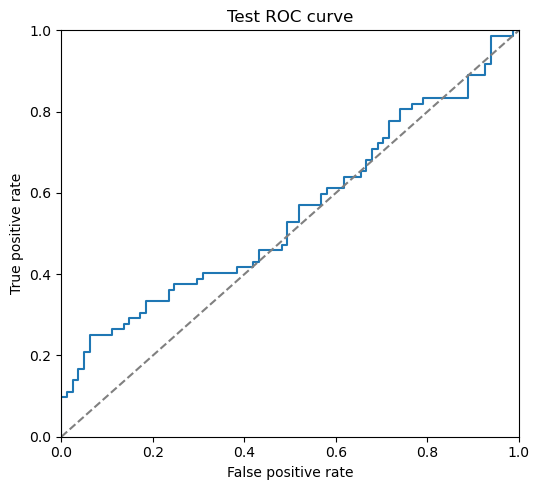

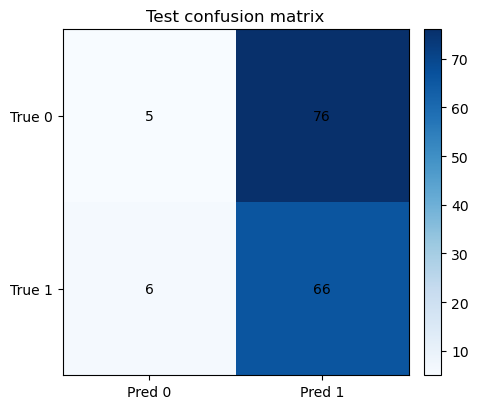

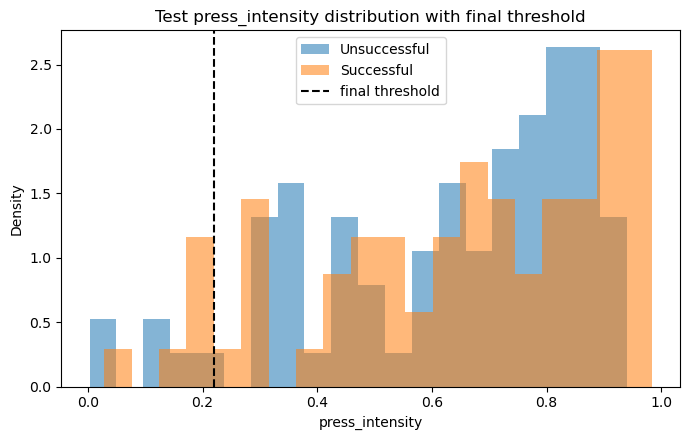

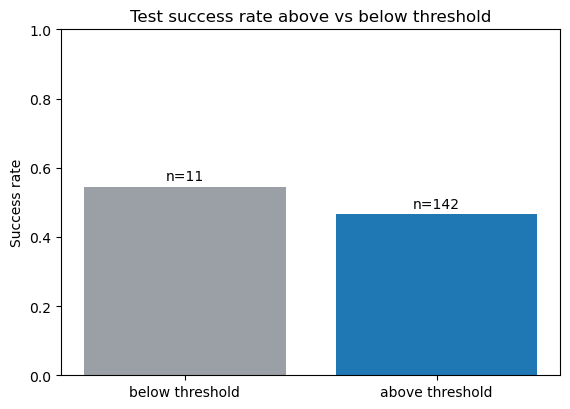

In [11]:
PLOT_THRESHOLD_CURVES_PATH = OUTPUT_DIR / "research_press_intensity_threshold_curves.png"
PLOT_PR_CURVE_PATH = OUTPUT_DIR / "research_press_intensity_pr_curve.png"
PLOT_ROC_CURVE_PATH = OUTPUT_DIR / "research_press_intensity_roc_curve.png"
PLOT_CONFUSION_MATRIX_PATH = OUTPUT_DIR / "research_press_intensity_test_confusion_matrix.png"
PLOT_TEST_DISTRIBUTION_PATH = OUTPUT_DIR / "research_press_intensity_test_distribution_threshold.png"
PLOT_ABOVE_BELOW_PATH = OUTPUT_DIR / "research_press_intensity_success_above_below_threshold.png"

fig, ax = plt.subplots(figsize=(8, 4.8))
for metric in ["precision", "recall", "f1"]:
    ax.plot(validation_threshold_results["threshold"], validation_threshold_results[metric], label=f"validation {metric}")
ax.axvline(final_threshold, color="black", linestyle="--", linewidth=1, label="final threshold")
ax.set_title("Validation threshold metrics")
ax.set_xlabel("press_intensity threshold")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_THRESHOLD_CURVES_PATH, dpi=220, bbox_inches="tight")
plt.show()

if test_df["press_success_any"].nunique() == 2:
    precision, recall, _ = precision_recall_curve(test_df["press_success_any"], test_df["press_intensity"])
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.plot(recall, precision)
    ax.set_title("Test precision-recall curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(PLOT_PR_CURVE_PATH, dpi=220, bbox_inches="tight")
    plt.show()

    fpr, tpr, _ = roc_curve(test_df["press_success_any"], test_df["press_intensity"])
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
    ax.set_title("Test ROC curve")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(PLOT_ROC_CURVE_PATH, dpi=220, bbox_inches="tight")
    plt.show()

cm = confusion_matrix(test_predictions["press_success_any"], test_predictions["press_success_pred"], labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], labels=["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
ax.set_title("Test confusion matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(PLOT_CONFUSION_MATRIX_PATH, dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for target, label in [(0, "Unsuccessful"), (1, "Successful")]:
    subset = test_predictions[test_predictions["press_success_any"].eq(target)]
    ax.hist(subset["press_intensity"], bins=20, alpha=0.55, label=label, density=True)
ax.axvline(final_threshold, color="black", linestyle="--", label="final threshold")
ax.set_title("Test press_intensity distribution with final threshold")
ax.set_xlabel("press_intensity")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_TEST_DISTRIBUTION_PATH, dpi=220, bbox_inches="tight")
plt.show()

above_below = pd.DataFrame({
    "group": ["below threshold", "above threshold"],
    "success_rate": [test_threshold_metrics["success_rate_below_threshold"], test_threshold_metrics["success_rate_above_threshold"]],
    "n": [test_threshold_metrics["n_below_threshold"], test_threshold_metrics["n_above_threshold"]],
})
fig, ax = plt.subplots(figsize=(5.8, 4.2))
ax.bar(above_below["group"], above_below["success_rate"], color=["#9aa0a6", "#1f77b4"])
ax.set_ylim(0, 1)
ax.set_title("Test success rate above vs below threshold")
ax.set_ylabel("Success rate")
for idx, row in above_below.iterrows():
    label_height = row["success_rate"] + 0.02 if pd.notna(row["success_rate"]) else 0.02
    ax.text(idx, label_height, f"n={int(row['n'])}", ha="center")
fig.tight_layout()
fig.savefig(PLOT_ABOVE_BELOW_PATH, dpi=220, bbox_inches="tight")
plt.show()

In [12]:
if RUN_OPTIONAL_LOGISTIC_REGRESSION:
    logit = LogisticRegression(solver="lbfgs")
    logit.fit(train_df[["press_intensity"]], train_df["press_success_any"].astype(int))

    rows = []
    for split_name, split_df in [("train", train_df), ("validation", validation_df), ("test", test_df)]:
        probs = logit.predict_proba(split_df[["press_intensity"]])[:, 1]
        preds = (probs >= 0.5).astype(int)
        y_true = split_df["press_success_any"].astype(int).to_numpy()
        rows.append({
            "split": split_name,
            "accuracy": accuracy_score(y_true, preds),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
            "roc_auc": roc_auc_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan,
            "pr_auc": average_precision_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan,
        })

    logistic_results = pd.DataFrame(rows)
    logistic_results.to_csv(OUTPUT_DIR / "research_press_intensity_logistic_regression_results.csv", index=False)
    display(logistic_results)
    print(f"Logistic coefficient: {float(logit.coef_[0][0]):.4f}; intercept: {float(logit.intercept_[0]):.4f}")

,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,train,0.541420,0.544601,0.666667,0.599483,0.567739,0.593647
1,validation,0.562963,0.551282,0.641791,0.593103,0.622476,0.660456
2,test,0.496732,0.477064,0.722222,0.574586,0.550412,0.596104


Logistic coefficient: 0.7875; intercept: -0.3935


## Thesis Interpretation Template

Use the final cell output below as the basis for the thesis text. The correct claim is that early research-based pressing intensity predicts pressing success. Do not claim that success is predicted before the press starts, because `press_intensity` is computed over the first second after press onset.

In [13]:
summary = (
    f"Using only research-paper press_intensity, the validation-selected threshold was {final_threshold:.3f}. "
    f"On the untouched test set, presses above this threshold succeeded at "
    f"{test_threshold_metrics['success_rate_above_threshold']:.3f}, compared with "
    f"{test_threshold_metrics['success_rate_below_threshold']:.3f} below the threshold. "
    f"The threshold model achieved precision={test_threshold_metrics['precision']:.3f}, "
    f"recall={test_threshold_metrics['recall']:.3f}, F1={test_threshold_metrics['f1']:.3f}, "
    f"ROC-AUC={test_threshold_metrics['roc_auc']:.3f}, and PR-AUC={test_threshold_metrics['pr_auc']:.3f}."
)
print(summary)
print(f"Saved outputs in: {OUTPUT_DIR}")

Using only research-paper press_intensity, the validation-selected threshold was 0.219. On the untouched test set, presses above this threshold succeeded at 0.465, compared with 0.545 below the threshold. The threshold model achieved precision=0.465, recall=0.917, F1=0.617, ROC-AUC=0.550, and PR-AUC=0.596.
Saved outputs in: /Users/jonasaalbaekjensen/Desktop/MASTER_DS_SDU/Superliga_2024_2025_selected_TEST_DATA_3MATCHES/research_press_intensity_model_outputs
